# Telecom X - Análisis de Evasión de Clientes

1️⃣ Importación de librerías

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

sns.set(style="whitegrid")

2️⃣ Extracción de datos desde la API



In [47]:
# Cargar datos desde la API
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

# Normalizar el JSON para convertirlo en tabla
df = pd.json_normalize(data)

# Visualizar primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


3️⃣ Exploración inicial del dataset

In [48]:
# Información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [49]:
# Estadísticas descriptivas

df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [50]:
# Ver columnas

df.columns.tolist()

['customerID',
 'Churn',
 'customer.gender',
 'customer.SeniorCitizen',
 'customer.Partner',
 'customer.Dependents',
 'customer.tenure',
 'phone.PhoneService',
 'phone.MultipleLines',
 'internet.InternetService',
 'internet.OnlineSecurity',
 'internet.OnlineBackup',
 'internet.DeviceProtection',
 'internet.TechSupport',
 'internet.StreamingTV',
 'internet.StreamingMovies',
 'account.Contract',
 'account.PaperlessBilling',
 'account.PaymentMethod',
 'account.Charges.Monthly',
 'account.Charges.Total']

4️⃣ Comprobación de incoherencias en los datos

In [51]:
# Verificar valores nulos
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [52]:
# Verificar duplicados
df.duplicated().sum()

np.int64(0)

In [53]:
# Revisar valores únicos en columnas categóricas
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumna: {col}")
    print(df[col].unique()[:10])  # muestra hasta 10 valores


Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ'
 '0013-MHZWF' '0013-SMEOE' '0014-BMAQU' '0015-UOCOJ' '0016-QLJIS']

Columna: Churn
['No' 'Yes' '']

Columna: customer.gender
['Female' 'Male']

Columna: customer.Partner
['Yes' 'No']

Columna: customer.Dependents
['Yes' 'No']

Columna: phone.PhoneService
['Yes' 'No']

Columna: phone.MultipleLines
['No' 'Yes' 'No phone service']

Columna: internet.InternetService
['DSL' 'Fiber optic' 'No']

Columna: internet.OnlineSecurity
['No' 'Yes' 'No internet service']

Columna: internet.OnlineBackup
['Yes' 'No' 'No internet service']

Columna: internet.DeviceProtection
['No' 'Yes' 'No internet service']

Columna: internet.TechSupport
['Yes' 'No' 'No internet service']

Columna: internet.StreamingTV
['Yes' 'No' 'No internet service']

Columna: internet.StreamingMovies
['No' 'Yes' 'No internet service']

Columna: account.Contract
['One year' 'Month-to-month' 'Two year']

Columna: account.PaperlessBilling
['Yes' 'N

5️⃣ Limpieza de datos


In [54]:
# Eliminar duplicados
df = df.drop_duplicates()

In [55]:
# Estandarizar texto en columnas categóricas
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [56]:
# Reemplazar cadenas vacías por valores nulos
df = df.replace(r'^\s*$', pd.NA, regex=True)

In [57]:
# Verificar nuevamente nulos después de limpieza
df.isnull().sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


6️⃣ Ajuste de nombres de columnas

In [58]:
# Renombrar columnas para facilitar el análisis
df = df.rename(columns={
    'customerID': 'cliente_id',
    'Churn': 'churn',
    'customer.gender': 'gender',
    'customer.SeniorCitizen': 'senior_citizen',
    'customer.Partner': 'partner',
    'customer.Dependents': 'dependents',
    'customer.tenure': 'tenure',
    'phone.PhoneService': 'phone_service',
    'phone.MultipleLines': 'multiple_lines',
    'internet.InternetService': 'internet_service',
    'internet.OnlineSecurity': 'online_security',
    'internet.OnlineBackup': 'online_backup',
    'internet.DeviceProtection': 'device_protection',
    'internet.TechSupport': 'tech_support',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_movies',
    'account.Contract': 'contract',
    'account.PaperlessBilling': 'paperless_billing',
    'account.PaymentMethod': 'payment_method',
    'account.Charges.Monthly': 'monthly_charges',
    'account.Charges.Total': 'total_charges'
})

df.columns.tolist()

['cliente_id',
 'churn',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges']

7️⃣ Conversión de tipos de datos

In [59]:
# Convertir cargos a numérico
df['monthly_charges'] = pd.to_numeric(df['monthly_charges'], errors='coerce')
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

In [60]:
# Verificar tipos de datos
df.dtypes

,0
cliente_id,object
churn,object
gender,object
senior_citizen,int64
partner,object
dependents,object
tenure,int64
phone_service,object
multiple_lines,object
internet_service,object


8️⃣ Estandarización y transformación de datos

In [61]:
# Convertir variables binarias yes/no a 1/0
binary_cols = ['partner', 'dependents', 'phone_service', 'paperless_billing', 'churn']

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'yes': 1, 'no': 0})

In [62]:
# Convertir género a formato más uniforme
if 'gender' in df.columns:
    df['gender'] = df['gender'].replace({'female': 'female', 'male': 'male'})

In [63]:
# Revisar resultado
df.head()

,cliente_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges
0,0002-orfbo,0.0,female,0,1,1,9,1,no,dsl,...,yes,no,yes,yes,no,one year,1,mailed check,65.6,593.30
1,0003-mknfe,0.0,male,0,0,0,9,1,yes,dsl,...,no,no,no,no,yes,month-to-month,0,mailed check,59.9,542.40
2,0004-tlhlj,1.0,male,0,0,0,4,1,no,fiber optic,...,no,yes,no,no,no,month-to-month,1,electronic check,73.9,280.85
3,0011-igkff,1.0,male,1,1,0,13,1,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,1,electronic check,98.0,1237.85
4,0013-exchz,1.0,female,1,1,0,3,1,no,fiber optic,...,no,no,yes,yes,no,month-to-month,1,mailed check,83.9,267.40


9️⃣ Columna de cuentas diarias

In [64]:
# Crear columna de cuentas diarias a partir del cargo mensual
df['cuentas_diarias'] = (df['monthly_charges'] / 30).round(2)

df[['monthly_charges', 'cuentas_diarias']].head()

,monthly_charges,cuentas_diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


🔟 Análisis descriptivo

In [65]:
# Resumen estadístico de variables numéricas
df.describe()

,churn,senior_citizen,partner,dependents,tenure,phone_service,paperless_billing,monthly_charges,total_charges,cuentas_diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.265370,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2280.634213,2.157292
std,0.441561,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.632997,1.004407
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,400.225000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3785.300000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [66]:
# Media, mediana y desviación estándar
print("Media:")
print(df.mean(numeric_only=True))

print("\nMediana:")
print(df.median(numeric_only=True))

print("\nDesviación estándar:")
print(df.std(numeric_only=True))

Media:
churn                   0.265370
senior_citizen          0.162653
partner                 0.484106
dependents              0.300124
tenure                 32.346498
phone_service           0.902711
paperless_billing       0.593230
monthly_charges        64.720098
total_charges        2280.634213
cuentas_diarias         2.157292
dtype: float64

Mediana:
churn                   0.00
senior_citizen          0.00
partner                 0.00
dependents              0.00
tenure                 29.00
phone_service           1.00
paperless_billing       1.00
monthly_charges        70.30
total_charges        1391.00
cuentas_diarias         2.34
dtype: float64

Desviación estándar:
churn                   0.441561
senior_citizen          0.369074
partner                 0.499782
dependents              0.458343
tenure                 24.571773
phone_service           0.296371
paperless_billing       0.491265
monthly_charges        30.129572
total_charges        2268.632997
cuentas_diaria

1️⃣1️⃣ Distribución de evasión

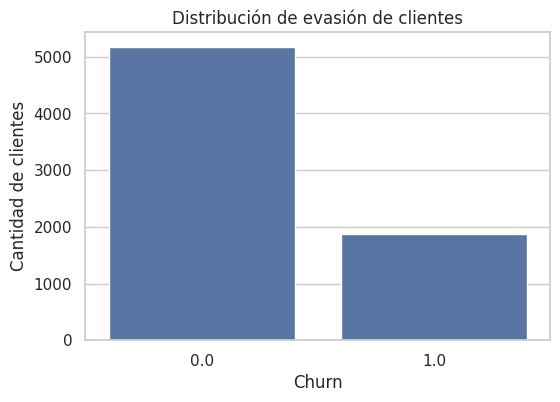

In [67]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='churn')
plt.title("Distribución de evasión de clientes")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.show()

In [68]:
# Porcentaje de evasión
df['churn'].value_counts(normalize=True) * 100

,proportion
churn,
0.0,73.463013
1.0,26.536987


1️⃣2️⃣ Recuento de evasión por variables categóricas

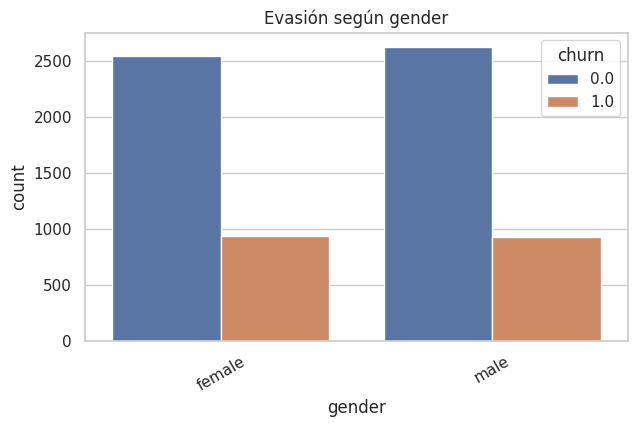

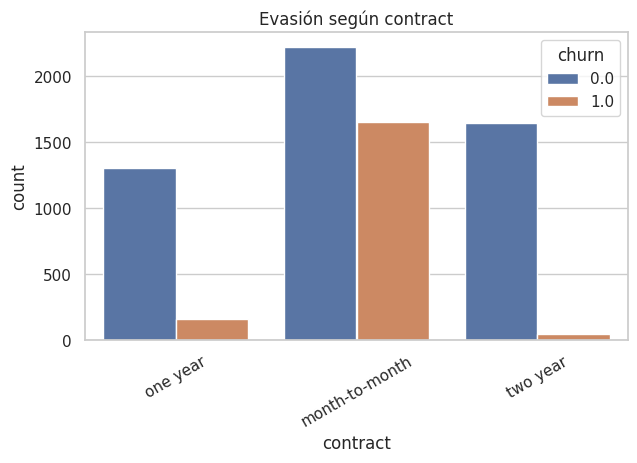

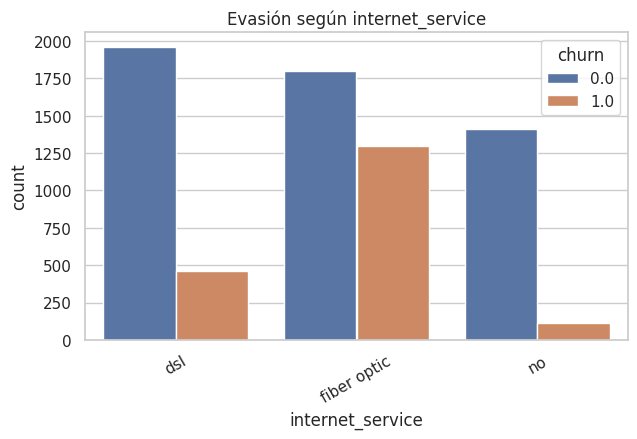

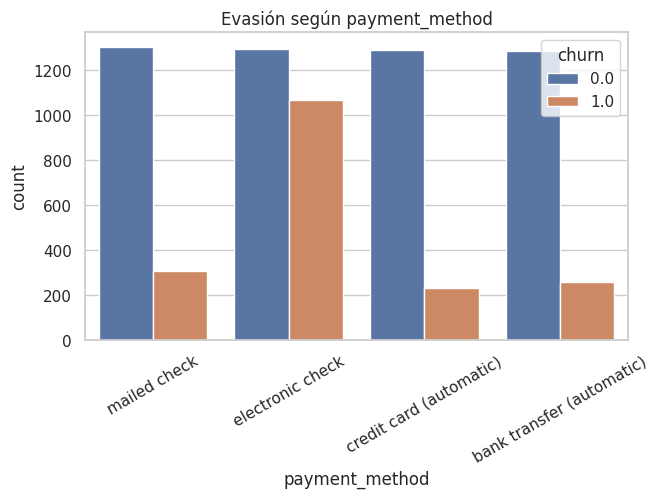

In [69]:
categorical_vars = [
    'gender',
    'contract',
    'internet_service',
    'payment_method'
]

for col in categorical_vars:
    if col in df.columns:
        plt.figure(figsize=(7,4))
        sns.countplot(data=df, x=col, hue='churn')
        plt.title(f"Evasión según {col}")
        plt.xticks(rotation=30)
        plt.show()

1️⃣3️⃣ Conteo de evasión por variables numéricas

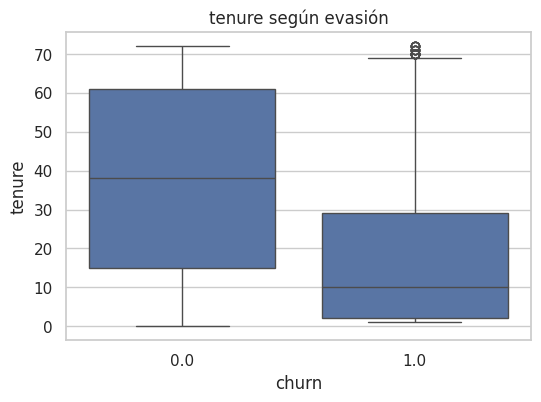

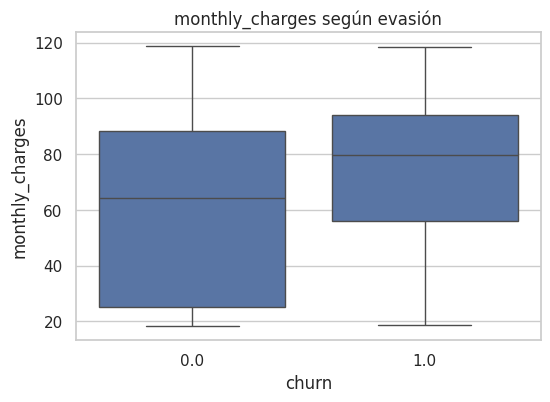

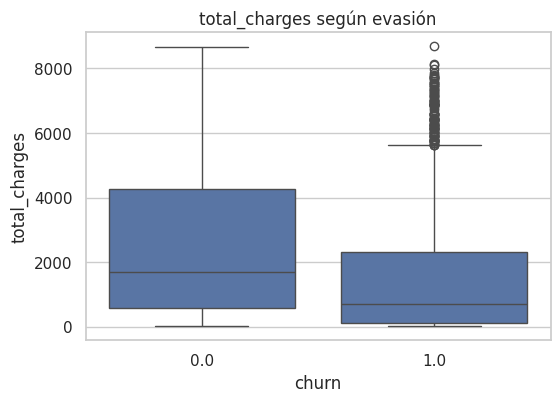

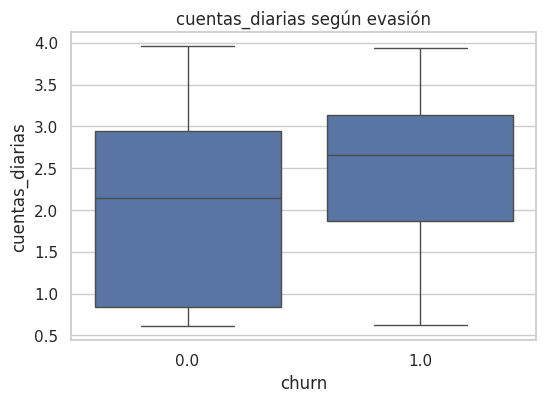

In [70]:
numeric_vars = ['tenure', 'monthly_charges', 'total_charges', 'cuentas_diarias']

for col in numeric_vars:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(data=df, x='churn', y=col)
        plt.title(f"{col} según evasión")
        plt.show()

1️⃣4️⃣ Análisis de correlación entre variables

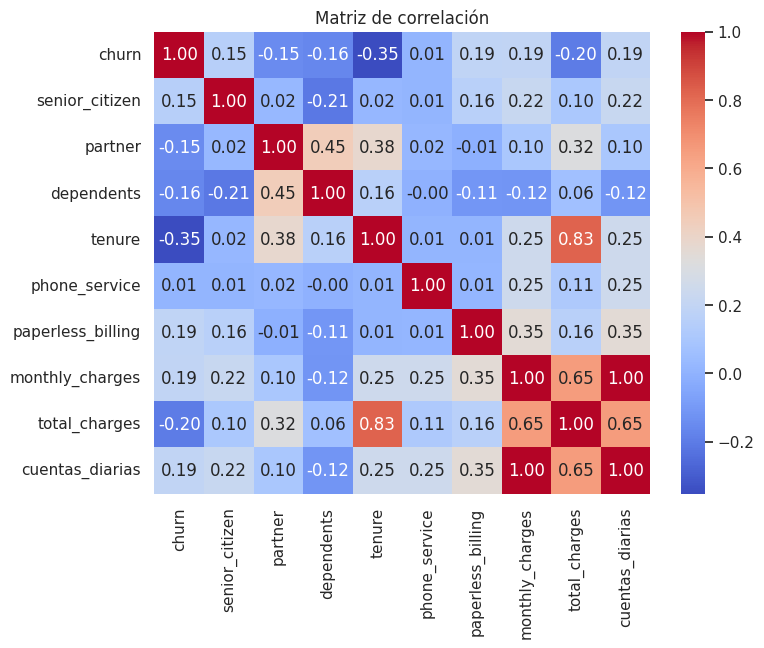

In [71]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

1️⃣5️⃣ Informe final

## Introducción

La evasión de clientes (churn) representa uno de los principales desafíos para las empresas de telecomunicaciones, ya que afecta directamente la estabilidad de los ingresos y la fidelización de los usuarios. El presente análisis tiene como objetivo explorar los datos de clientes de Telecom X para identificar patrones asociados con la cancelación del servicio.

## Limpieza y tratamiento de datos

Los datos fueron extraídos desde una API en formato JSON y posteriormente normalizados para convertirlos en una estructura tabular adecuada para el análisis. Se revisaron valores nulos, duplicados e inconsistencias en las categorías, además de realizar transformaciones en variables binarias y conversiones de tipo de datos en columnas numéricas.

También se creó la variable `cuentas_diarias`, calculada a partir de los cargos mensuales, con el fin de obtener una medida complementaria del comportamiento de gasto de los clientes.

## Análisis exploratorio de datos

Se realizó un análisis descriptivo de las variables numéricas y categóricas, así como visualizaciones enfocadas en la distribución de la evasión. Posteriormente, se exploró la relación entre churn y variables categóricas como tipo de contrato, servicio de internet y método de pago, además de analizar variables numéricas como antigüedad del cliente, cargos mensuales y cargos totales.

Adicionalmente, se construyó una matriz de correlación para identificar relaciones entre las variables numéricas.

## Conclusiones e insights

Los resultados sugieren que la evasión se concentra más en clientes con contratos mensuales, menor antigüedad y mayores cargos mensuales. En contraste, los clientes con contratos de mayor duración y más tiempo en la empresa presentan menor tendencia a cancelar el servicio.

Estos hallazgos indican que la evasión no ocurre de forma aleatoria, sino que está asociada a características específicas del cliente y del servicio contratado.

## Recomendaciones

- Diseñar estrategias de retención para clientes nuevos durante sus primeros meses.
- Incentivar contratos de mayor duración mediante promociones o beneficios.
- Revisar los planes con mayores cargos mensuales para mejorar la percepción de valor.
- Utilizar estos hallazgos como base para futuros modelos predictivos de churn.